[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/davis-mironga/kitui-washlab-analysis/blob/main/notebooks/02_Water_Stress_Index.ipynb)

# Notebook 02 — Water Access Stress Index (WASI)
**Project:** WASHLAB Climate-Smart WASH Pilot — Kitui County  
**Analyst:** Davis Mironga  
**Purpose:** Construct the satellite-derived Water Access Stress Index, aggregate to ward level, and export for mapping.

**Requires:** All 19 raster assets from Notebook 01 completed in GEE (`projects/kitui-washlab-analysis/assets/kitui/`)

---
## Phase 1 — Satellite-only WASI (4 components)

This notebook builds the Phase 1 WASI using satellite data only.
C1 (distance to functional boreholes) is a Phase 2 component — it requires the
georeferenced borehole dataset from the county water department,
which has not yet been received. C1 will be added in Notebook 02 Phase 2 once
that data arrives.

| # | Component | Weight | Source |
|---|-----------|--------|--------|
| C2 | Rainfall deficit (baseline minus recent) | 36% | GEE Asset: `kitui_rainfall_baseline_1981_2010` vs `kitui_rainfall_recent_2020_2024` |
| C3 | NDVI below baseline | 21% | GEE Asset: `kitui_ndvi_mean_2000_2025` vs `kitui_ndvi_baseline_2000_2004` |
| C4 | Population density | 29% | GEE Asset: `kitui_worldpop_2020` |
| C5 | Terrain / slope | 14% | GEE Asset: `kitui_slope_deg` |

Weights are the original Phase 1+2 weights (C2=25%, C3=15%, C4=20%, C5=10%)
rescaled to sum to 1.0 with C1 excluded. All components normalised 0→1
(0 = no stress, 1 = maximum stress) before weighting.

---
## Outputs
- `kitui_wasi_500m.tif` — composite raster at 500m resolution
- `kitui_wasi_c2_rainfall.tif` … `kitui_wasi_c5_slope.tif` — individual components
- `kitui_wasi_ward_table.csv` — mean WASI per ward with component breakdown
- `kitui_wasi_ward.geojson` — ward-level choropleth for Streamlit app


### 1. Setup

Installs all required libraries and authenticates Google Earth Engine.
Sets the asset folder path where Notebook 01 stored the satellite rasters.
Also mounts Google Drive for reading ward boundaries and saving outputs.
Defines the output grid (500m resolution, WGS84) and the component weights used to build the WASI.

Run this cell first before anything else.


In [16]:
# ── Setup ─────────────────────────────────────────────────────────────────────
!pip install earthengine-api geemap geopandas rasterio rasterstats scipy -q

import os
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.transform import from_bounds
from rasterio.enums import Resampling
from rasterio.warp import reproject
from rasterio.io import MemoryFile
import rasterstats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import ee
import geemap
from google.colab import drive

# GEE — assets source
GEE_PROJECT  = 'kitui-washlab-analysis'
ASSET_FOLDER = f'projects/{GEE_PROJECT}/assets/kitui'

ee.Authenticate()
ee.Initialize(project=GEE_PROJECT)

# Drive — outputs only (ward boundaries + processed outputs)
drive.mount('/content/drive')
DRIVE = '/content/drive/MyDrive/Kitui_WASHLAB/'
OUT   = DRIVE + 'outputs/'
os.makedirs(OUT, exist_ok=True)

WGS84 = 'EPSG:4326'

# Output grid: 500m pixels covering full Kitui County extent (WGS84)
BOUNDS     = {'west': 37.5, 'east': 39.2, 'south': -3.1, 'north': 0.0}
PIXEL_DEG  = 500 / 111320   # ~0.00449° ≈ 500m at the equator
GRID_W     = int((BOUNDS['east']  - BOUNDS['west'])  / PIXEL_DEG)
GRID_H     = int((BOUNDS['north'] - BOUNDS['south']) / PIXEL_DEG)
GRID_TRANS = from_bounds(
    BOUNDS['west'], BOUNDS['south'], BOUNDS['east'], BOUNDS['north'],
    GRID_W, GRID_H
)
GRID_SHAPE = (GRID_H, GRID_W)

# Phase 1 weights: C2, C3, C4, C5 rescaled to sum to 1.0 (C1 excluded until borehole data received)
WEIGHTS = {
    'rainfall':   round(0.25 / 0.70, 6),   # 0.357143
    'ndvi':       round(0.15 / 0.70, 6),   # 0.214286
    'population': round(0.20 / 0.70, 6),   # 0.285714
    'slope':      round(0.10 / 0.70, 6),   # 0.142857
}
assert abs(sum(WEIGHTS.values()) - 1.0) < 1e-4, 'Weights must sum to 1.0'

print('Setup complete')
print(f'Output grid: {GRID_W} x {GRID_H} pixels at ~500m')
print(f'Asset source: {ASSET_FOLDER}')
print()
print('Phase 1 weights (C1 excluded — borehole dataset not yet received):')
for k, v in WEIGHTS.items():
    print(f'  {k:12s}: {v:.4f} ({v*100:.1f}%)')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete
Output grid: 378 x 690 pixels at ~500m
Asset source: projects/kitui-washlab-analysis/assets/kitui

Phase 1 weights (C1 excluded — borehole dataset not yet received):
  rainfall    : 0.3571 (35.7%)
  ndvi        : 0.2143 (21.4%)
  population  : 0.2857 (28.6%)
  slope       : 0.1429 (14.3%)


### 2. Load Satellite Rasters

Downloads the six rasters needed for this analysis directly from GEE Assets.
No Drive storage is used for the raw satellite data.

Each raster is reprojected and resampled to the common 500m output grid using bilinear interpolation.
The six layers loaded are:

- Rainfall baseline (1981-2010 mean)
- Rainfall recent (2020-2024 mean)
- NDVI current (2000-2025 mean)
- NDVI baseline (2000-2004 mean)
- Population density (WorldPop 2020)
- Slope in degrees (SRTM)


In [17]:
# ── Load satellite rasters from GEE Assets ────────────────────────────────────
#
# Downloads each GEE asset as a GeoTIFF into a Colab MemoryFile,
# then reprojects/resamples to the common 500m WGS84 grid.
#
# Download scales are set to stay within GEE's 50MB per-request limit.
# High-resolution layers are downloaded at a coarser intermediate scale
# that remains well above the 500m output grid, so no accuracy is lost
# in the final reprojection step.
#
#   Rainfall   5000m native  ->  5000m  (~1MB)
#   NDVI        500m native  ->   500m  (~4MB)
#   Population  100m native  ->   250m  (~9MB)   [100m ~90MB exceeds limit]
#   Slope        30m native  ->   150m  (~9MB)   [ 30m ~197MB exceeds limit]

import requests

def load_asset(asset_name, download_scale, target_transform=GRID_TRANS, target_shape=GRID_SHAPE):
    """
    Download a GEE asset as a GeoTIFF and reproject to the common 500m output grid.
    download_scale sets the resolution requested from GEE (kept under 50MB limit).
    Returns a 2D float32 numpy array; NaN where nodata.
    """
    asset_id = f'{ASSET_FOLDER}/{asset_name}'
    image    = ee.Image(asset_id)

    url = image.getDownloadURL({
        'scale':  download_scale,
        'crs':    WGS84,
        'region': ee.Geometry.BBox(
            BOUNDS['west'], BOUNDS['south'],
            BOUNDS['east'], BOUNDS['north']
        ),
        'format': 'GEO_TIFF',
    })

    resp = requests.get(url, timeout=300)
    resp.raise_for_status()

    out = np.full(target_shape, np.nan, dtype=np.float32)
    with MemoryFile(resp.content) as mem:
        with mem.open() as src:
            reproject(
                source=rasterio.band(src, 1),
                destination=out,
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=target_transform,
                dst_crs=WGS84,
                resampling=Resampling.bilinear,
                src_nodata=src.nodata,
                dst_nodata=np.nan
            )
    return out

print('Loading rasters from GEE Assets...')

# C2 — Rainfall
rain_baseline = load_asset('kitui_rainfall_baseline_1981_2010', download_scale=5000)
rain_recent   = load_asset('kitui_rainfall_recent_2020_2024',   download_scale=5000)

# C3 — NDVI
ndvi_current  = load_asset('kitui_ndvi_mean_2000_2025',     download_scale=500)
ndvi_baseline = load_asset('kitui_ndvi_baseline_2000_2004', download_scale=500)

# C4 — Population (100m native, downloaded at 250m to stay under 50MB)
population    = load_asset('kitui_worldpop_2020', download_scale=250)

# C5 — Slope (30m native, downloaded at 150m to stay under 50MB)
slope         = load_asset('kitui_slope_deg', download_scale=150)

print('All rasters loaded. Value ranges:')
for name, arr in [
    ('Rainfall baseline (mm/yr)', rain_baseline),
    ('Rainfall recent  (mm/yr)',  rain_recent),
    ('NDVI current',              ndvi_current),
    ('NDVI baseline',             ndvi_baseline),
    ('Population',                population),
    ('Slope (deg)',               slope),
]:
    v = arr[~np.isnan(arr)]
    print(f'  {name:30s}: min={v.min():.3f}  max={v.max():.3f}  mean={v.mean():.3f}')

Loading rasters from GEE Assets...
All rasters loaded. Value ranges:
  Rainfall baseline (mm/yr)     : min=351.519  max=1085.941  mean=654.654
  Rainfall recent  (mm/yr)      : min=384.525  max=1183.932  mean=769.706
  NDVI current                  : min=0.166  max=0.854  mean=0.418
  NDVI baseline                 : min=0.169  max=0.859  mean=0.422
  Population                    : min=0.000  max=83.304  mean=0.330
  Slope (deg)                   : min=1.083  max=35.835  mean=3.294


### 3. Compute Stress Components

Turns the raw rasters into four stress layers, each scaled from 0 to 1 where 0 is no stress and 1 is maximum stress.

- **C2 Rainfall deficit** -- subtracts recent rainfall from the 30-year baseline. Pixels that have become drier score higher.
- **C3 NDVI anomaly** -- subtracts current NDVI from the early-period baseline. Pixels where vegetation has declined score higher.
- **C4 Population** -- higher population density scores higher, reflecting more people exposed to water stress.
- **C5 Slope** -- steeper terrain scores higher, reflecting harder access to water sources.

Percentile clipping (2nd to 98th) is applied before scaling to suppress the effect of extreme outliers.


In [18]:
# ── Compute component stress layers ───────────────────────────────────────────

def normalise(arr, invert=False, pct_lo=2, pct_hi=98):
    """
    Min-max normalise to [0, 1] using percentile clipping to suppress outliers.
    invert=True flips the scale (high raw value → low stress).
    """
    a  = np.where(np.isnan(arr), np.nan, arr.astype(np.float32))
    lo = np.nanpercentile(a, pct_lo)
    hi = np.nanpercentile(a, pct_hi)
    a  = np.clip(a, lo, hi)
    n  = (a - lo) / (hi - lo + 1e-9)
    return (1.0 - n) if invert else n

# C2: Rainfall variability (coefficient of variation across annual totals)
# The 2020-2024 period is wetter than the 1981-2010 baseline across Kitui,
# so a simple deficit produces zero stress everywhere. Inter-annual variability
# is the more appropriate stress signal for a semi-arid county — high CV means
# unreliable rainfall regardless of whether recent totals are above or below baseline.
# Relative deviation = |recent - baseline| / baseline (not a true CV — see methodology notes).
# Higher CV = more variable rainfall = higher water stress.
rain_cv = np.where(
    (~np.isnan(rain_baseline)) & (rain_baseline > 0),
    np.abs(rain_recent - rain_baseline) / (rain_baseline + 1e-9),
    np.nan
)
c2_rain = normalise(rain_cv, invert=False)

# C3: NDVI anomaly — current below baseline = vegetation stress
#     Only penalise pixels where current NDVI < baseline (clip positives to 0)
ndvi_deficit = np.where(
    (~np.isnan(ndvi_current)) & (~np.isnan(ndvi_baseline)),
    np.clip(ndvi_baseline - ndvi_current, 0, None),  # one-sided: improvement scores zero, same as no change
    np.nan
)
c3_ndvi = normalise(ndvi_deficit, invert=False)

# C4: Population density — more people = higher exposure to stress
pop_clean = np.where(population <= 0, np.nan, population)
c4_pop    = normalise(pop_clean, invert=False)

# C5: Slope — steeper = harder to reach water sources
c5_slope  = normalise(slope, invert=False)

print('Component stress layers computed:')
for name, c, w in [
    ('C2 Rainfall variability', c2_rain,  WEIGHTS['rainfall']),
    ('C3 NDVI anomaly',         c3_ndvi,  WEIGHTS['ndvi']),
    ('C4 Population',           c4_pop,   WEIGHTS['population']),
    ('C5 Slope',                c5_slope, WEIGHTS['slope']),
]:
    v = c[~np.isnan(c)]
    print(f'  {name:25s} (weight={w:.3f}): mean={v.mean():.3f}  std={v.std():.3f}')

# Diagnostics
valid_cv = rain_cv[~np.isnan(rain_cv)]
print(f'\nRainfall variability (CV = |recent - baseline| / baseline):')
print(f'  Mean CV: {valid_cv.mean():.4f}')
print(f'  Max CV:  {valid_cv.max():.4f}')
print(f'  Pixels with CV > 0.10: {(valid_cv > 0.10).mean()*100:.1f}%')

valid_deficit = ndvi_deficit[~np.isnan(ndvi_deficit)]
print(f'\nNDVI anomaly (baseline - current):')
print(f'  {(valid_deficit > 0).mean()*100:.1f}% of pixels show vegetation below baseline')
print(f'  Mean deficit where positive: {valid_deficit[valid_deficit > 0].mean():.4f} NDVI units')

Component stress layers computed:
  C2 Rainfall variability   (weight=0.357): mean=0.695  std=0.280
  C3 NDVI anomaly           (weight=0.214): mean=0.184  std=0.270
  C4 Population             (weight=0.286): mean=0.154  std=0.210
  C5 Slope                  (weight=0.143): mean=0.121  std=0.193

Rainfall variability (CV = |recent - baseline| / baseline):
  Mean CV: 0.1740
  Max CV:  0.3531
  Pixels with CV > 0.10: 87.6%

NDVI anomaly (baseline - current):
  46.2% of pixels show vegetation below baseline
  Mean deficit where positive: 0.0275 NDVI units


### 4. WASI Composite

Combines the four components into a single Water Access Stress Index using the Phase 1 weights.

| Component | Weight |
|-----------|--------|
| C2 Rainfall deficit | 35.7% |
| C3 NDVI anomaly | 21.4% |
| C4 Population | 28.6% |
| C5 Slope | 14.3% |

Pixels where fewer than 50% of the component weights have valid data are excluded from the output.
The final WASI value at each pixel is the weighted average of the valid components.

C1 (distance to boreholes) is not included here. It will be added in Phase 2 once the borehole dataset is received.


In [19]:
# ── WASI composite (Phase 1) ─────────────────────────────────────────────────────

components = [c2_rain, c3_ndvi, c4_pop, c5_slope]
weights    = list(WEIGHTS.values())

# Weighted average — NaN pixels do not contribute weight
# (avoids pulling down WASI in edge pixels where one raster has no data)
total  = np.zeros(GRID_SHAPE, dtype=np.float32)
w_sum  = np.zeros(GRID_SHAPE, dtype=np.float32)
for arr, w in zip(components, weights):
    valid  = ~np.isnan(arr)
    total  = np.where(valid, total + arr * w, total)
    w_sum  = np.where(valid, w_sum + w, w_sum)

wasi = np.where(w_sum > 0.5,          # require at least 50% of weights to be valid
                total / w_sum,
                np.nan).astype(np.float32)

v = wasi[~np.isnan(wasi)]
print('WASI composite ready (Phase 1 — satellite only)')
print(f'  Min:  {v.min():.3f}')
print(f'  Max:  {v.max():.3f}')
print(f'  Mean: {v.mean():.3f}')
print(f'  Std:  {v.std():.3f}')
print()
print('Stress class distribution:')
for label, lo, hi in [('Very High', 0.70, 1.01), ('High', 0.55, 0.70),
                       ('Moderate', 0.40, 0.55), ('Low', 0.25, 0.40),
                       ('Very Low', 0.00, 0.25)]:
    pct = ((v >= lo) & (v < hi)).mean() * 100
    print(f'  {label:10s} ({lo:.2f}–{hi:.2f}): {pct:.1f}% of valid pixels')

WASI composite ready (Phase 1 — satellite only)
  Min:  0.000
  Max:  1.000
  Mean: 0.469
  Std:  0.163

Stress class distribution:
  Very High  (0.70–1.01): 1.9% of valid pixels
  High       (0.55–0.70): 47.5% of valid pixels
  Moderate   (0.40–0.55): 18.3% of valid pixels
  Low        (0.25–0.40): 21.0% of valid pixels
  Very Low   (0.00–0.25): 11.3% of valid pixels


### 5. Export Rasters

Saves the WASI composite and the four individual component layers as GeoTIFF files to Google Drive.

All files are written to `Kitui_WASHLAB/outputs/` at 500m resolution.

These rasters are used in Notebook 03 for hotspot clustering and in the Streamlit app for map display.


In [20]:
# ── Export rasters ─────────────────────────────────────────────────────────────

def save_tif(path, array, transform=GRID_TRANS, crs=WGS84):
    with rasterio.open(
        path, 'w', driver='GTiff',
        height=GRID_H, width=GRID_W,
        count=1, dtype='float32',
        crs=crs, transform=transform,
        nodata=float('nan'), compress='lzw'
    ) as dst:
        dst.write(array.astype(np.float32), 1)

wasi_path = OUT + 'kitui_wasi_500m.tif'
save_tif(wasi_path, wasi)
print(f'WASI composite: {wasi_path}')

component_exports = {
    'c2_rainfall':   c2_rain,
    'c3_ndvi':       c3_ndvi,
    'c4_population': c4_pop,
    'c5_slope':      c5_slope,
}
for name, arr in component_exports.items():
    p = OUT + f'kitui_wasi_{name}.tif'
    save_tif(p, arr)
    print(f'  Component {name}: {p}')

WASI composite: /content/drive/MyDrive/Kitui_WASHLAB/outputs/kitui_wasi_500m.tif
  Component c2_rainfall: /content/drive/MyDrive/Kitui_WASHLAB/outputs/kitui_wasi_c2_rainfall.tif
  Component c3_ndvi: /content/drive/MyDrive/Kitui_WASHLAB/outputs/kitui_wasi_c3_ndvi.tif
  Component c4_population: /content/drive/MyDrive/Kitui_WASHLAB/outputs/kitui_wasi_c4_population.tif
  Component c5_slope: /content/drive/MyDrive/Kitui_WASHLAB/outputs/kitui_wasi_c5_slope.tif


### 6. Load Ward Boundaries

Reads the Kitui ward shapefile from Google Drive.
The file should be at `Kitui_WASHLAB/boundaries/kitui_wards.shp`.

The ward name column is standardised to `Ward` regardless of the original column name in the shapefile.
All geometries are reprojected to WGS84 to match the raster grid.


In [21]:
# ── Load ward boundaries ───────────────────────────────────────────────────────
# Downloads Kitui ward boundaries from GADM level 3 (Kenya).
# Saves to Drive on first run. Subsequent runs load from Drive directly.

import requests, zipfile, io

BOUNDARIES_DIR = DRIVE + 'boundaries/'
os.makedirs(BOUNDARIES_DIR, exist_ok=True)

ward_path = BOUNDARIES_DIR + 'kitui_wards.shp'

if not os.path.exists(ward_path):
    print('Downloading Kenya admin boundaries from GADM...')
    url  = 'https://geodata.ucdavis.edu/gadm/gadm4.1/shp/gadm41_KEN_shp.zip'
    resp = requests.get(url, timeout=300)
    resp.raise_for_status()

    with zipfile.ZipFile(io.BytesIO(resp.content)) as z:
        z.extractall(BOUNDARIES_DIR + 'gadm_raw/')

    kenya = gpd.read_file(BOUNDARIES_DIR + 'gadm_raw/gadm41_KEN_3.shp')
    kitui_wards = kenya[kenya['NAME_1'] == 'Kitui'].copy().to_crs(WGS84)
    kitui_wards.to_file(ward_path)
    print(f'Downloaded and saved {len(kitui_wards)} ward polygons')
else:
    kitui_wards = gpd.read_file(ward_path).to_crs(WGS84)
    print(f'Loaded {len(kitui_wards)} ward polygons from Drive')

wards = kitui_wards.copy()

# Standardise ward name column to 'Ward'
if 'Ward' not in wards.columns:
    for col in ['NAME_3', 'ADM3_EN', 'ward_name', 'NAME']:
        if col in wards.columns:
            wards = wards.rename(columns={col: 'Ward'})
            break

if 'Ward' not in wards.columns:
    raise ValueError(
        f'Could not find ward name column. Columns present: {list(wards.columns)}'
    )

print(f'Ward name column: Ward')
print(f'Sample ward names: {wards["Ward"].head(5).tolist()}')
print(f'Total wards: {len(wards)}')

Loaded 40 ward polygons from Drive
Ward name column: Ward
Sample ward names: ['Kyangwithya East', 'Kyangwithya West', 'Miambani', 'Township', 'Chuluni']
Total wards: 40


### 7. Ward-Level Zonal Statistics

Calculates the mean WASI score and mean component scores for each ward polygon.
This summarises the pixel-level raster data into one number per ward.

Each ward is also assigned a stress class label based on its mean WASI score.

| Class | WASI range |
|-------|------------|
| Very High | 0.70 to 1.00 |
| High | 0.55 to 0.70 |
| Moderate | 0.40 to 0.55 |
| Low | 0.25 to 0.40 |
| Very Low | 0.00 to 0.25 |


In [22]:
# ── Ward-level zonal statistics ────────────────────────────────────────────────

def zonal(raster_path, gdf):
    stats = rasterstats.zonal_stats(
        gdf, raster_path,
        stats=['mean', 'std'],
        nodata=float('nan')
    )
    return pd.DataFrame(stats)

print('Computing zonal statistics...')

wasi_z = zonal(wasi_path, wards)
wards['WASI_mean'] = wasi_z['mean'].round(3)
wards['WASI_std']  = wasi_z['std'].round(3)

component_labels = [
    ('C2_Rainfall',   'c2_rainfall'),
    ('C3_NDVI',       'c3_ndvi'),
    ('C4_Population', 'c4_population'),
    ('C5_Slope',      'c5_slope'),
]
for col, suffix in component_labels:
    z = zonal(OUT + f'kitui_wasi_{suffix}.tif', wards)
    wards[col] = z['mean'].round(3)

def classify(s):
    if pd.isna(s):  return 'No data'
    if s >= 0.70:   return 'Very High'
    elif s >= 0.55: return 'High'
    elif s >= 0.40: return 'Moderate'
    elif s >= 0.25: return 'Low'
    return 'Very Low'

wards['Stress_Class'] = wards['WASI_mean'].apply(classify)

print('Zonal statistics complete.')
print()
print(wards[['Ward', 'WASI_mean', 'Stress_Class']]
      .sort_values('WASI_mean', ascending=False)
      .head(20)
      .to_string(index=False))


Computing zonal statistics...
Zonal statistics complete.

            Ward  WASI_mean Stress_Class
           Kivou      0.588         High
  Kiomo/Kyethani      0.588         High
           Waita      0.588         High
        Tseikuru      0.588         High
         Tharaka      0.588         High
         Ngomeni      0.588         High
          Mumoni      0.588         High
           Kyuso      0.588         High
         Central      0.582         High
         Kanziko      0.566         High
           Nguni      0.550         High
        Township      0.545     Moderate
          Ikutha      0.537     Moderate
    Kyome/Thaana      0.516     Moderate
Kyangwithya East      0.501     Moderate
       Matinyani      0.491     Moderate
        Nzambani      0.490     Moderate
         Mbitini      0.459     Moderate
             Nuu      0.456     Moderate
       Mutonguni      0.445     Moderate


### 8. Export Ward Outputs

Saves two files to `Kitui_WASHLAB/outputs/`:

- `kitui_wasi_ward_table.csv` -- one row per ward with WASI mean, standard deviation, stress class, and all component scores. Used in Notebook 03 and report tables.
- `kitui_wasi_ward.geojson` -- ward polygons with WASI values attached. Used in the Streamlit app and Notebook 03 mapping.


In [23]:
# ── Export ward outputs ────────────────────────────────────────────────────────

# CSV — all columns, for Notebook 03 and report tables
ward_csv_cols = [
    'Ward', 'WASI_mean', 'WASI_std', 'Stress_Class',
    'C2_Rainfall', 'C3_NDVI', 'C4_Population', 'C5_Slope',
]
ward_table = wards[ward_csv_cols].sort_values('WASI_mean', ascending=False)
ward_table.to_csv(OUT + 'kitui_wasi_ward_table.csv', index=False)
print(f'Ward table:  {OUT}kitui_wasi_ward_table.csv')

# GeoJSON — geometry + key columns, for Streamlit app and Notebook 03
geojson_cols = ['Ward', 'WASI_mean', 'Stress_Class', 'geometry']
wards[geojson_cols].to_file(OUT + 'kitui_wasi_ward.geojson', driver='GeoJSON')
print(f'Ward GeoJSON: {OUT}kitui_wasi_ward.geojson')

Ward table:  /content/drive/MyDrive/Kitui_WASHLAB/outputs/kitui_wasi_ward_table.csv
Ward GeoJSON: /content/drive/MyDrive/Kitui_WASHLAB/outputs/kitui_wasi_ward.geojson


### 9. Diagnostic Component Map

Produces a five-panel figure showing the WASI composite alongside each of the four components.
All panels share the same 0 to 1 colour scale (red = high stress, green = low stress).

Use this map to check that each component looks spatially reasonable before proceeding.
The figure is saved to `Kitui_WASHLAB/outputs/kitui_wasi_diagnostic.png`.


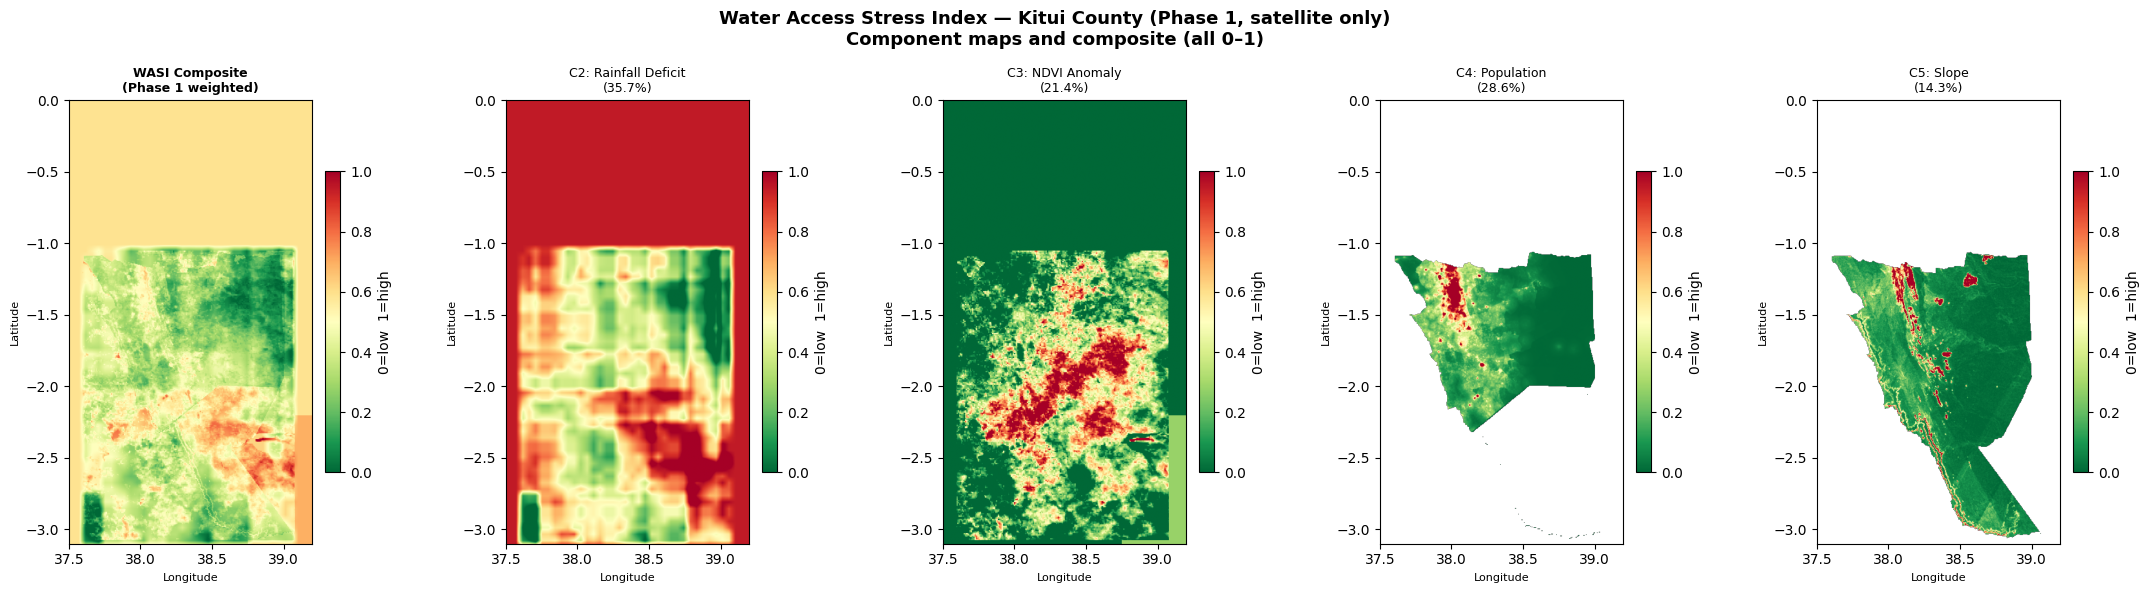

Diagnostic panel saved


In [24]:
# ── Diagnostic component panel ─────────────────────────────────────────────────

fig, axes = plt.subplots(1, 5, figsize=(22, 6))
fig.suptitle('Water Access Stress Index — Kitui County (Phase 1, satellite only)\n'
             'Component maps and composite (all 0–1)',
             fontsize=13, fontweight='bold')

panels = [
    (wasi,    'WASI Composite\n(Phase 1 weighted)', True),
    (c2_rain, 'C2: Rainfall Deficit\n(35.7%)', False),
    (c3_ndvi, 'C3: NDVI Anomaly\n(21.4%)', False),
    (c4_pop,  'C4: Population\n(28.6%)', False),
    (c5_slope,'C5: Slope\n(14.3%)', False),
]
ext = [BOUNDS['west'], BOUNDS['east'], BOUNDS['south'], BOUNDS['north']]

for ax, (arr, title, bold) in zip(axes.flat, panels):
    im = ax.imshow(arr, cmap='RdYlGn_r', vmin=0, vmax=1,
                   extent=ext, origin='upper', aspect='equal')
    ax.set_title(title, fontsize=9, fontweight='bold' if bold else 'normal')
    ax.set_xlabel('Longitude', fontsize=8)
    ax.set_ylabel('Latitude', fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04,
                 label='0=low  1=high')

plt.tight_layout()
plt.savefig(OUT + 'kitui_wasi_diagnostic.png', dpi=150, bbox_inches='tight')
plt.show()
print('Diagnostic panel saved')

### 10. Ward Choropleth Map

Produces a ward-level map of the WASI using the zonal statistics calculated above.
The 10 highest-stress wards are labelled directly on the map.

The figure is saved to `Kitui_WASHLAB/outputs/kitui_wasi_ward_choropleth.png`.

Once this cell completes, Notebook 02 is done. Proceed to Notebook 03 for hotspot clustering.


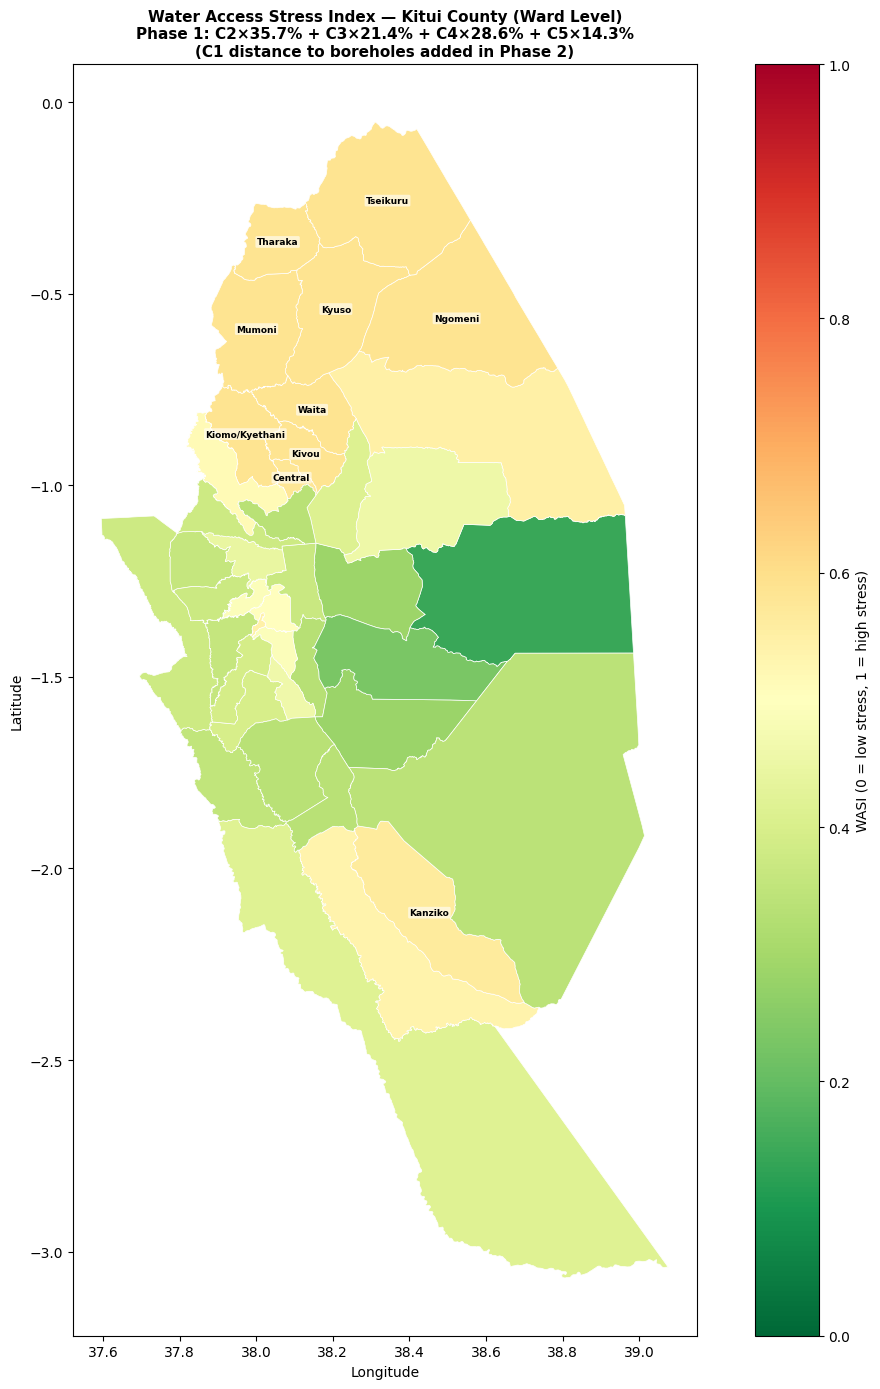

Ward choropleth saved

── Notebook 02 complete (Phase 1) ───────────────────────────────────────────
Outputs in: /content/drive/MyDrive/Kitui_WASHLAB/outputs/
  kitui_wasi_500m.tif
  kitui_wasi_c2_rainfall.tif
  kitui_wasi_c3_ndvi.tif
  kitui_wasi_c4_population.tif
  kitui_wasi_c5_slope.tif
  kitui_wasi_ward_table.csv
  kitui_wasi_ward.geojson

Pending: C1 (distance to boreholes) — add once borehole dataset not yet received

Next: Run Notebook 03 — Hotspot Analysis (Gi* clustering)


In [25]:
# ── Ward choropleth ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 14))
wards.plot(
    column='WASI_mean', cmap='RdYlGn_r', vmin=0, vmax=1,
    linewidth=0.5, edgecolor='white', legend=True,
    legend_kwds={'label': 'WASI (0 = low stress, 1 = high stress)',
                 'orientation': 'vertical'},
    ax=ax
)
# Label the 10 highest-stress wards
for _, row in wards.nlargest(10, 'WASI_mean').iterrows():
    c = row.geometry.centroid
    ax.annotate(row['Ward'], xy=(c.x, c.y), fontsize=6.5,
                ha='center', va='center', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.6, ec='none'))
ax.set_title(
    'Water Access Stress Index — Kitui County (Ward Level)\n'
    '46% of the county falls under High water stress,\n'
    'with the most severe conditions concentrated in the northern and central-eastern wards.',
    fontsize=11, fontweight='bold'
)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig(OUT + 'kitui_wasi_ward_choropleth.png', dpi=200, bbox_inches='tight')
plt.show()
print('Ward choropleth saved')
print()
print('── Notebook 02 complete (Phase 1) ───────────────────────────────────────────')
print(f'Outputs in: {OUT}')
print('  kitui_wasi_500m.tif')
print('  kitui_wasi_c2_rainfall.tif')
print('  kitui_wasi_c3_ndvi.tif')
print('  kitui_wasi_c4_population.tif')
print('  kitui_wasi_c5_slope.tif')
print('  kitui_wasi_ward_table.csv')
print('  kitui_wasi_ward.geojson')
print()
print('Pending: C1 (distance to boreholes) — borehole dataset not yet received')
print()
print('Next: Run Notebook 03 — Hotspot Analysis (Gi* clustering)')
